# gensort - Experiment 6: Heatmap Analysis (Exp6 vs Exp1)


In [244]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp6_output'

# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [245]:
def parse_log_file_with_io(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            result['m4_read_mb'] = float(io_avg_match.group(9)) if io_avg_match.group(9) else 0.0
            result['m4_write_mb'] = float(io_avg_match.group(10)) if io_avg_match.group(10) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'] +
                                     result['m4_read_mb'] + result['m4_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file_with_io(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 41 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [246]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

# Exp6 vs Exp1: Combined Heatmap Analysis

Comparing independent RunGen/Merge configurations (Exp6) vs symmetric configurations (Exp1).

In [247]:
import os
import re
import glob
from matplotlib.colors import BoundaryNorm, ListedColormap

def parse_exp6_log(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r'Exp6_RunGen(\d+)_Merge(\d+)_Mem2GB\.log', filename)
    if not match:
        return None
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract all metrics including rungen_time and merge_time
    avg_match = re.search(r'Exp6_RunGen\d+_Merge\d+_Mem2GB\[avg\]\s+[\d.]+\s+\d+\s+\d+\s+\d+\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+\d+\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', content)
    if not avg_match:
        return None
    
    return {
        'rungen_threads': int(match.group(1)),
        'merge_threads': int(match.group(2)),
        'total_time': float(avg_match.group(1)),
        'rungen_time': float(avg_match.group(2)),
        'merge_time': float(avg_match.group(3)),
        'throughput': float(avg_match.group(4)),
        'total_io_mb': float(avg_match.group(5)) + float(avg_match.group(6))
    }

def parse_exp1_log_heatmap(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r'Exp1_Thr(\d+)_Mem2GB\.log', filename)
    if not match:
        return None
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Extract all metrics including rungen_time and merge_time
    avg_match = re.search(r'Exp1_Thr\d+_Mem2GB\[avg\]\s+[\d.]+\s+\d+\s+\d+\s+\d+\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+\d+\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)', content)
    if not avg_match:
        return None
    
    return {
        'threads': int(match.group(1)),
        'total_time': float(avg_match.group(1)),
        'rungen_time': float(avg_match.group(2)),
        'merge_time': float(avg_match.group(3)),
        'throughput': float(avg_match.group(4)),
        'total_io_mb': float(avg_match.group(5)) + float(avg_match.group(6))
    }

# Load data
exp6_data = [parse_exp6_log(f) for f in glob.glob('./result/Exp6_*.log')]
exp6_data = [d for d in exp6_data if d is not None]
df_exp6_hm = pd.DataFrame(exp6_data)

exp1_data = [parse_exp1_log_heatmap(f) for f in glob.glob('./result/Exp1_Thr*_Mem2GB.log')]
exp1_data = [d for d in exp1_data if d is not None]
df_exp1_hm = pd.DataFrame(exp1_data)

print(f"Loaded {len(df_exp6_hm)} Exp6 and {len(df_exp1_hm)} Exp1 configurations")
print(f"\nSample Exp6 data:")
print(df_exp6_hm.head())
print(f"\nSample Exp1 data:")
print(df_exp1_hm.head())

Loaded 42 Exp6 and 7 Exp1 configurations

Sample Exp6 data:
   rungen_threads  merge_threads  total_time  rungen_time  merge_time  throughput  total_io_mb
0              44             16     1265.26       634.66      630.60        1.70     954714.9
1               4             32     2584.32      1960.25      624.07        0.83     918260.7
2              16              4     1726.22       794.42      931.80        1.24     917844.1
3              44              4     1636.22       636.94      999.28        1.31     918433.9
4              16             40     1306.03       752.24      553.78        1.64     921309.6

Sample Exp1 data:
   threads  total_time  rungen_time  merge_time  throughput  total_io_mb
0       40     1343.01       486.97      856.04        1.60    1207944.6
1        8     1764.47      1044.71      719.76        1.22     917868.2
2       44     1311.05       462.44      848.61        1.64    1244040.1
3       32     1304.87       562.60      742.27        1.65

In [248]:
# Get all unique thread values
all_threads_hm = sorted(set(df_exp6_hm['rungen_threads'].tolist()) |
                        set(df_exp6_hm['merge_threads'].tolist()) |
                        set(df_exp1_hm['threads'].tolist()))

n = len(all_threads_hm)
time_mat = np.full((n, n), np.nan)
io_mat = np.full((n, n), np.nan)
tput_mat = np.full((n, n), np.nan)

# Fill Exp6 data
for _, row in df_exp6_hm.iterrows():
    i = all_threads_hm.index(row['rungen_threads'])
    j = all_threads_hm.index(row['merge_threads'])
    time_mat[i, j] = row['total_time']
    io_mat[i, j] = row['total_io_mb']
    tput_mat[i, j] = row['throughput']

# Fill Exp1 data on diagonal
for _, row in df_exp1_hm.iterrows():
    idx = all_threads_hm.index(row['threads'])
    time_mat[idx, idx] = row['total_time']
    io_mat[idx, idx] = row['total_io_mb']
    tput_mat[idx, idx] = row['throughput']

# Convert units
time_mat = time_mat / 60  # to minutes
io_mat = io_mat / 1024  # to GB

print(f"Matrix shape: {time_mat.shape}, Threads: {all_threads_hm}")

Matrix shape: (7, 7), Threads: [4, 8, 16, 24, 32, 40, 44]


In [249]:
def plot_heatmap(data, title, unit, fmt='.1f', invert=False):
    fig, ax = plt.subplots()
    n = len(all_threads_hm)
    
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', origin='lower',
                   vmin=np.nanmin(data), vmax=np.nanmax(data))
    
    # Annotations
    vmin, vmax = np.nanmin(data), np.nanmax(data)
    for i in range(n):
        for j in range(n):
            if not np.isnan(data[i, j]):
                val = data[i, j]
                norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5
                color = 'white' if (norm > 0.5) != invert else 'black'
                ax.text(j, i, f'{val:{fmt}}', ha='center', va='center',
                       color=color, fontsize=9, fontweight='bold')
    
    # Labels
    labels = [str(t) for t in all_threads_hm]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Merge Threads')
    ax.set_ylabel('RunGen Threads')
    # ax.set_title(title, fontweight='bold', pad=15)
    
    plt.colorbar(im, ax=ax, label=unit)
    
    # Diagonal line
    # ax.plot([-0.5, n-0.5], [-0.5, n-0.5], 'k--', lw=2, alpha=0.5, label='Exp1')
    
    # Mark optimal
    # opt = np.nanargmax(data) if invert else np.nanargmin(data)
    # oi, oj = np.unravel_index(opt, data.shape)
    # ax.plot(oj, oi, 'b*', ms=20, mew=2, mfc='none', label='Best')
    # ax.legend(loc='upper right')
    
    ax.grid(which='minor', color='gray', ls='-', lw=0.5, alpha=0.2)
    ax.set_xticks(np.arange(n) - 0.5, minor=True)
    ax.set_yticks(np.arange(n) - 0.5, minor=True)
    
    return fig

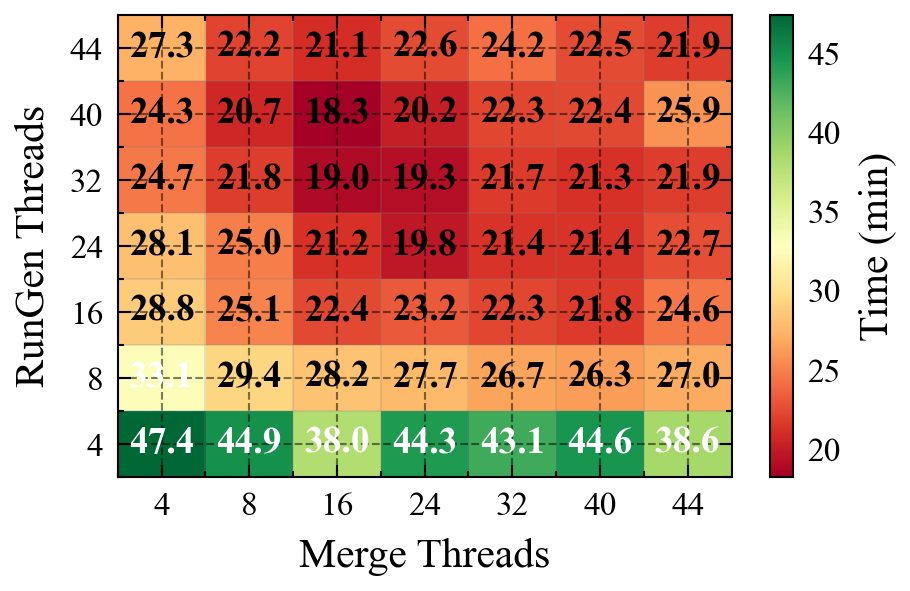

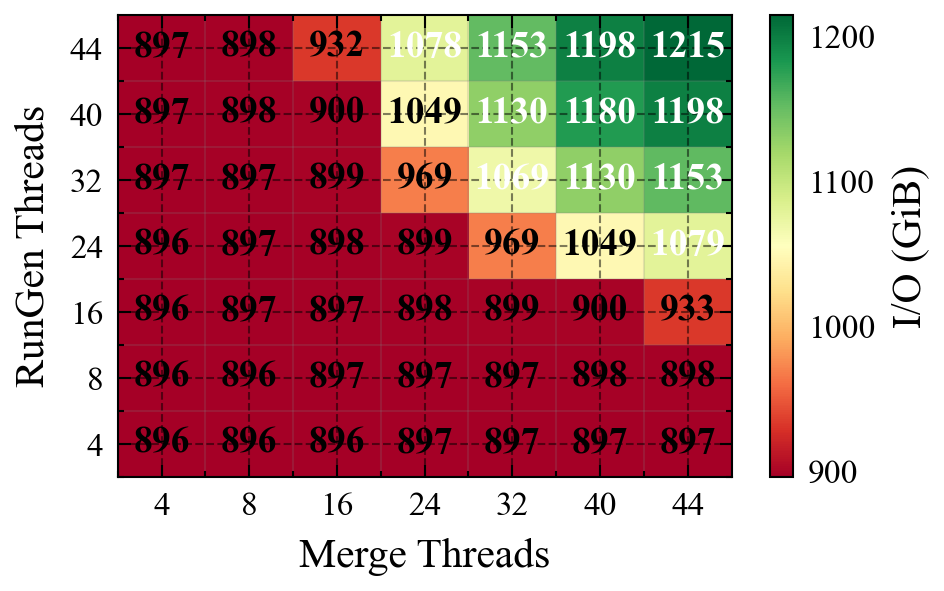

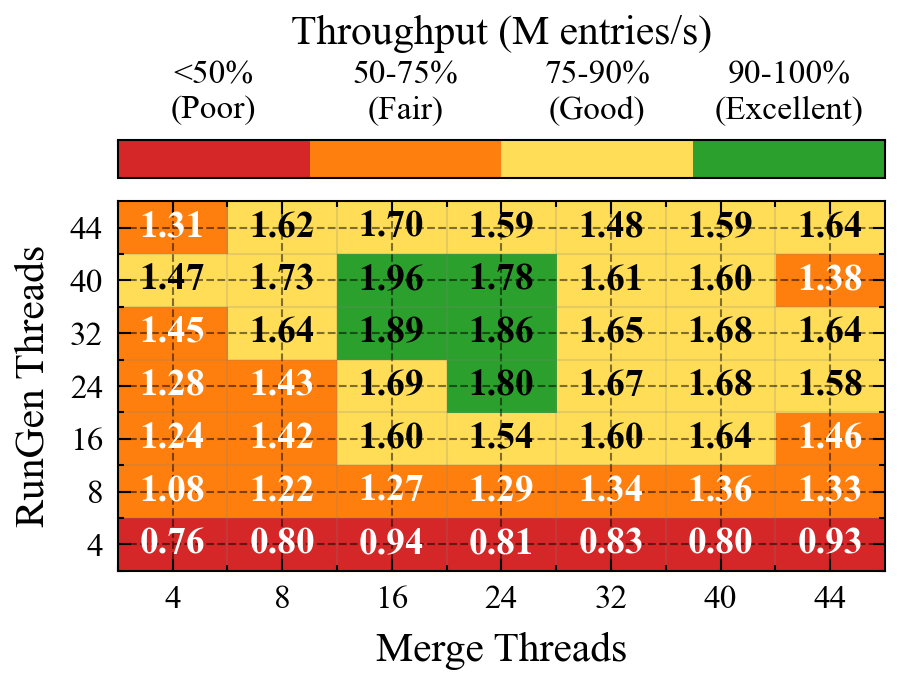

In [250]:
plot_heatmap(time_mat, 'GenSort: Total Time', 'Time (min)', '.1f')
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_exp1_total_time_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

plot_heatmap(io_mat, 'GenSort: Total I/O', 'I/O (GiB)', '.0f')
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_exp1_total_io_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Throughput heatmap with tier-based color coding
fig, ax = plt.subplots()
n = len(all_threads_hm)

# Calculate performance tiers based on percentage of best
max_tput = np.nanmax(tput_mat)
tput_tier_pct = (tput_mat / max_tput) * 100

# Define performance tiers (percentage of best)
boundaries = [0, 50, 75, 90, 100]
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c']  # Red, Orange, Light Yellow, Green
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

im = ax.imshow(tput_tier_pct, cmap=cmap, norm=norm, aspect='auto',
               interpolation='nearest', origin='lower')

# Add text annotations with actual throughput values
for i in range(n):
    for j in range(n):
        if not np.isnan(tput_mat[i, j]):
            value = tput_mat[i, j]
            text_str = f'{value:.2f}'

            # Determine text color based on tier
            tier_pct = tput_tier_pct[i, j]
            if tier_pct >= 75:
                text_color = 'black'
            else:
                text_color = 'white'

            ax.text(j, i, text_str, ha="center", va="center",
                   color=text_color, fontsize=9, fontweight='bold')

# Labels
labels = [str(t) for t in all_threads_hm]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Merge Threads')
ax.set_ylabel('RunGen Threads')

# Add colorbar with tier labels - RELOCATED TO TOP
cbar = plt.colorbar(im, ax=ax, location='top', label='Throughput (M entries/s)',
                   boundaries=boundaries, ticks=[25, 62.5, 82.5, 95])
cbar.ax.set_xticklabels(['<50%\n(Poor)', '50-75%\n(Fair)',
                         '75-90%\n(Good)', '90-100%\n(Excellent)'],
                        fontsize=8)

# Add grid for better readability
ax.set_xticks(np.arange(n) - 0.5, minor=True)
ax.set_yticks(np.arange(n) - 0.5, minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.2)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_exp1_throughput_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

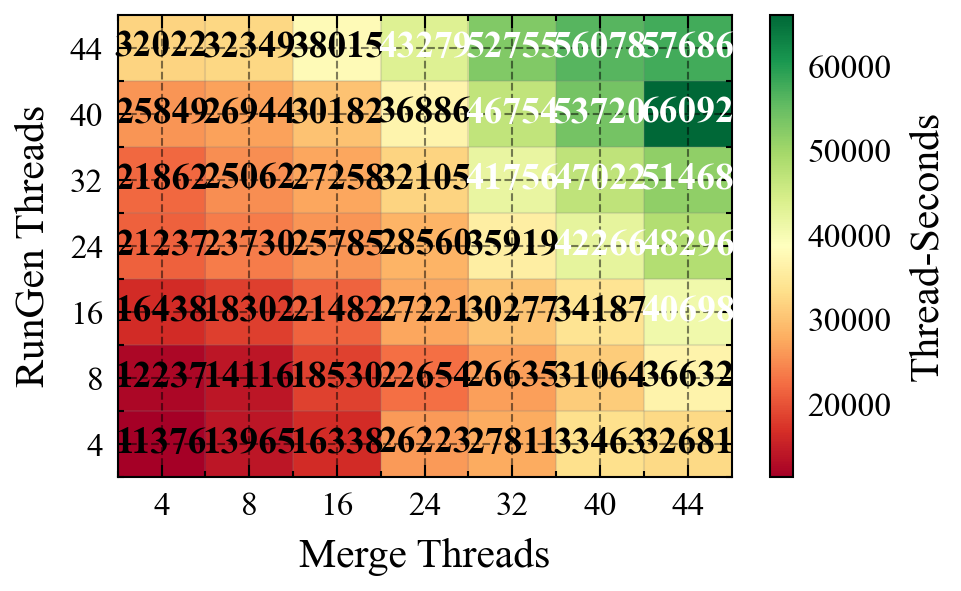

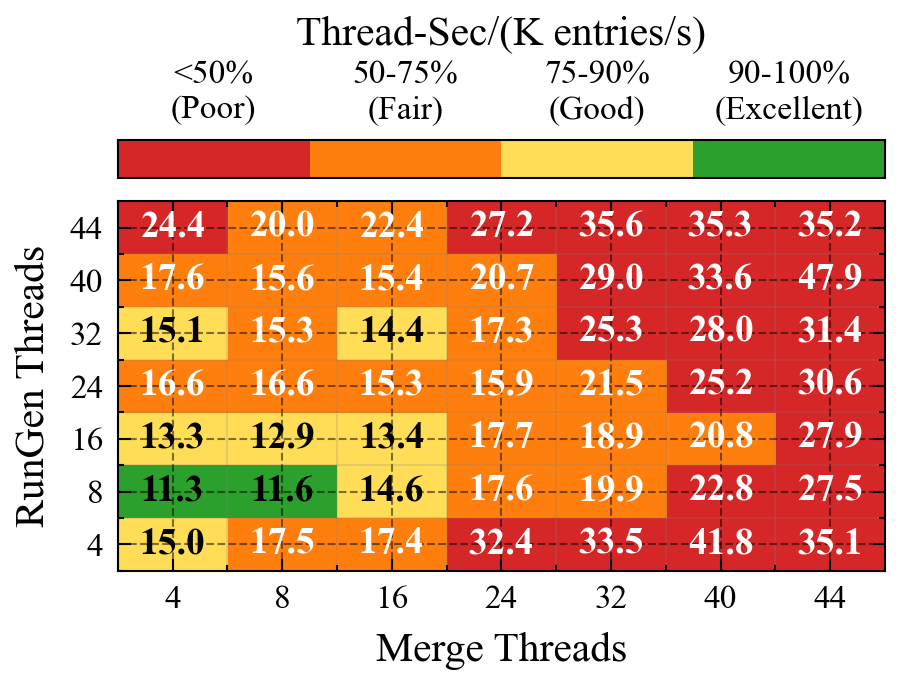

In [251]:
# ========== NEW: Resource Cost Heatmaps ==========
# Build resource cost matrix using correct formula
n = len(all_threads_hm)
resource_cost_mat = np.full((n, n), np.nan)
cost_per_tput_mat = np.full((n, n), np.nan)

# Fill Exp6 data with correct resource cost formula
for _, row in df_exp6_hm.iterrows():
    i = all_threads_hm.index(row['rungen_threads'])
    j = all_threads_hm.index(row['merge_threads'])
    # Resource cost = (rungen_threads × rungen_time) + (merge_threads × merge_time)
    resource_cost = row['rungen_threads'] * row['rungen_time'] + row['merge_threads'] * row['merge_time']
    resource_cost_mat[i, j] = resource_cost
    # Cost per throughput (lower is better)
    cost_per_tput_mat[i, j] = resource_cost / (row['throughput'] * 1000)  # per K entries/s

# Fill Exp1 data on diagonal with correct resource cost formula
for _, row in df_exp1_hm.iterrows():
    idx = all_threads_hm.index(row['threads'])
    # Resource cost = (threads × rungen_time) + (threads × merge_time)
    resource_cost = row['threads'] * row['rungen_time'] + row['threads'] * row['merge_time']
    resource_cost_mat[idx, idx] = resource_cost
    # Cost per throughput
    cost_per_tput_mat[idx, idx] = resource_cost / (row['throughput'] * 1000)

plot_heatmap(resource_cost_mat, 'GenSort: Resource Cost', 'Thread-Seconds', '.0f')
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_exp1_resource_cost_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Cost per throughput heatmap with tier-based color coding
fig, ax = plt.subplots()

# For cost metrics, lower is better, so we invert the percentage calculation
min_cost = np.nanmin(cost_per_tput_mat)
cost_efficiency_pct = (min_cost / cost_per_tput_mat) * 100

# Define performance tiers (percentage of best efficiency)
boundaries = [0, 50, 75, 90, 100]
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c']  # Red, Orange, Light Yellow, Green
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

im = ax.imshow(cost_efficiency_pct, cmap=cmap, norm=norm, aspect='auto',
               interpolation='nearest', origin='lower')

# Add text annotations with actual cost values
for i in range(n):
    for j in range(n):
        if not np.isnan(cost_per_tput_mat[i, j]):
            value = cost_per_tput_mat[i, j]
            text_str = f'{value:.1f}'

            # Determine text color based on tier
            tier_pct = cost_efficiency_pct[i, j]
            if tier_pct >= 75:
                text_color = 'black'
            else:
                text_color = 'white'

            ax.text(j, i, text_str, ha="center", va="center",
                   color=text_color, fontsize=9, fontweight='bold')

# Labels
labels = [str(t) for t in all_threads_hm]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Merge Threads')
ax.set_ylabel('RunGen Threads')

# Add colorbar with tier labels - RELOCATED TO TOP
cbar = plt.colorbar(im, ax=ax, location='top', label='Thread-Sec/(K entries/s)',
                   boundaries=boundaries, ticks=[25, 62.5, 82.5, 95])
cbar.ax.set_xticklabels(['<50%\n(Poor)', '50-75%\n(Fair)',
                         '75-90%\n(Good)', '90-100%\n(Excellent)'],
                        fontsize=8)

# Add grid for better readability
ax.set_xticks(np.arange(n) - 0.5, minor=True)
ax.set_yticks(np.arange(n) - 0.5, minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.2)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_exp1_cost_per_throughput_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

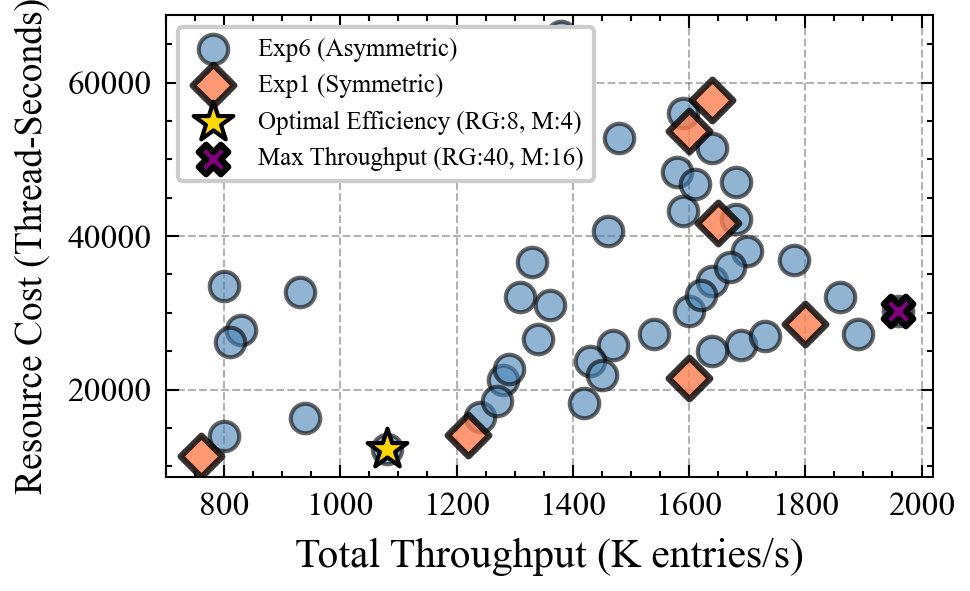

\n📊 Exp6 Marginal Gain Analysis:\n
Optimal Efficiency Point:
  - Config: RunGen 8, Merge 4 (Exp6)
  - Throughput: 1080.0K entries/s
  - Resource Cost: 12237 thread-seconds
  - Efficiency: 0.088 K entries/s per thread-second
\nMax Throughput Point:
  - Config: RunGen 40, Merge 16 (Exp6)
  - Throughput: 1960.0K entries/s
  - Resource Cost: 30182 thread-seconds
  - Efficiency: 0.065 K entries/s per thread-second
\nCost of Max Speed:
  - Cost multiplier: 2.47x
  - Throughput gain: 81.5%
  - Paying 2.5x more resources for 81.5% more speed
\n\n🔍 Configurations with Lowest Resource Costs:\n
Rank   Exp    RG    Merge  RGTime   MgTime   Tput(K)    Cost       Efficiency  
------------------------------------------------------------------------------------------
47     Exp1   4     4      1876.6   967.4    760.0      11376      0.0668      
23     Exp6   8     4      1074.7   909.9    1080.0     12237      0.0883      
36     Exp6   4     8      1894.0   798.6    800.0      13965      0.0573     

In [252]:
# Prepare data for marginal gain analysis
# Calculate resource cost CORRECTLY: (rungen_threads × rungen_time) + (merge_threads × merge_time)
df_exp6_hm['resource_cost'] = (df_exp6_hm['rungen_threads'] * df_exp6_hm['rungen_time'] + 
                                df_exp6_hm['merge_threads'] * df_exp6_hm['merge_time'])
df_exp6_hm['throughput_k'] = df_exp6_hm['throughput'] * 1000  # Convert to K entries/s

# Also add Exp1 data for comparison with correct resource cost
df_exp1_hm['resource_cost'] = (df_exp1_hm['threads'] * df_exp1_hm['rungen_time'] + 
                                df_exp1_hm['threads'] * df_exp1_hm['merge_time'])
df_exp1_hm['throughput_k'] = df_exp1_hm['throughput'] * 1000

# Create scatter plot
fig, ax = plt.subplots()

# Plot Exp6 data
scatter_exp6 = ax.scatter(df_exp6_hm['throughput_k'], df_exp6_hm['resource_cost'], 
                          s=50, alpha=0.6, c='steelblue', edgecolors='black', linewidth=1,
                          label='Exp6 (Asymmetric)')

# Plot Exp1 data
scatter_exp1 = ax.scatter(df_exp1_hm['throughput_k'], df_exp1_hm['resource_cost'],
                          s=50, alpha=0.8, c='coral', marker='D', edgecolors='black', linewidth=1.5,
                          label='Exp1 (Symmetric)')

# Find and mark the optimal point (best throughput per resource cost)
df_all_configs = pd.concat([
    df_exp6_hm[['throughput_k', 'resource_cost', 'rungen_threads', 'merge_threads', 'rungen_time', 'merge_time']].assign(exp='Exp6'),
    df_exp1_hm[['throughput_k', 'resource_cost', 'rungen_time', 'merge_time']].assign(
        exp='Exp1', 
        rungen_threads=df_exp1_hm['threads'], 
        merge_threads=df_exp1_hm['threads']
    )
], ignore_index=True)

# Calculate efficiency (throughput / resource_cost)
df_all_configs['efficiency'] = df_all_configs['throughput_k'] / df_all_configs['resource_cost']
optimal_idx = df_all_configs['efficiency'].idxmax()

# Extract scalar values
opt_rg = int(df_all_configs.loc[optimal_idx, 'rungen_threads'])
opt_mg = int(df_all_configs.loc[optimal_idx, 'merge_threads'])
opt_tput = float(df_all_configs.loc[optimal_idx, 'throughput_k'])
opt_cost = float(df_all_configs.loc[optimal_idx, 'resource_cost'])
opt_exp = str(df_all_configs.loc[optimal_idx, 'exp'])
opt_eff = float(df_all_configs.loc[optimal_idx, 'efficiency'])

ax.scatter([opt_tput], [opt_cost], 
           s=100, marker='*', color='gold', edgecolor='black', linewidth=1, zorder=5,
           label=f'Optimal Efficiency (RG:{opt_rg}, M:{opt_mg})')

# Find max throughput point
max_tput_idx = df_all_configs['throughput_k'].idxmax()

# Extract scalar values
max_rg = int(df_all_configs.loc[max_tput_idx, 'rungen_threads'])
max_mg = int(df_all_configs.loc[max_tput_idx, 'merge_threads'])
max_tput = float(df_all_configs.loc[max_tput_idx, 'throughput_k'])
max_cost = float(df_all_configs.loc[max_tput_idx, 'resource_cost'])
max_exp = str(df_all_configs.loc[max_tput_idx, 'exp'])
max_eff = float(df_all_configs.loc[max_tput_idx, 'efficiency'])

ax.scatter([max_tput], [max_cost], 
           s=50, marker='X', color='purple', edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Max Throughput (RG:{max_rg}, M:{max_mg})')

ax.set_xlabel('Total Throughput (K entries/s)')
ax.set_ylabel('Resource Cost (Thread-Seconds)', fontsize=9)
# ax.set_title('Exp6: Cost of Speed - Resource Usage vs Throughput\\n(Hockey Stick Analysis)', 
#              fontweight='bold', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp6_marginal_gain_scatter.png'), dpi=300)
plt.show()

# Print analysis
print("\\n📊 Exp6 Marginal Gain Analysis:\\n")
print(f"Optimal Efficiency Point:")
print(f"  - Config: RunGen {opt_rg}, Merge {opt_mg} ({opt_exp})")
print(f"  - Throughput: {opt_tput:.1f}K entries/s")
print(f"  - Resource Cost: {opt_cost:.0f} thread-seconds")
print(f"  - Efficiency: {opt_eff:.3f} K entries/s per thread-second")
print(f"\\nMax Throughput Point:")
print(f"  - Config: RunGen {max_rg}, Merge {max_mg} ({max_exp})")
print(f"  - Throughput: {max_tput:.1f}K entries/s")
print(f"  - Resource Cost: {max_cost:.0f} thread-seconds")
print(f"  - Efficiency: {max_eff:.3f} K entries/s per thread-second")
print(f"\\nCost of Max Speed:")
cost_multiplier = max_cost / opt_cost
tput_gain = (max_tput / opt_tput - 1) * 100
print(f"  - Cost multiplier: {cost_multiplier:.2f}x")
print(f"  - Throughput gain: {tput_gain:.1f}%")
print(f"  - Paying {cost_multiplier:.1f}x more resources for {tput_gain:.1f}% more speed")

# Print configurations with lowest resource costs
print("\\n\\n🔍 Configurations with Lowest Resource Costs:\\n")
print("=" * 90)
df_sorted_by_cost = df_all_configs.sort_values('resource_cost')
print(f"{'Rank':<6} {'Exp':<6} {'RG':<5} {'Merge':<6} {'RGTime':<8} {'MgTime':<8} {'Tput(K)':<10} {'Cost':<10} {'Efficiency':<12}")
print("-" * 90)
for i, row in df_sorted_by_cost.head(10).iterrows():
    print(f"{i+1:<6} {row['exp']:<6} {int(row['rungen_threads']):<5} {int(row['merge_threads']):<6} "
          f"{row['rungen_time']:<8.1f} {row['merge_time']:<8.1f} {row['throughput_k']:<10.1f} "
          f"{row['resource_cost']:<10.0f} {row['efficiency']:<12.4f}")